# Gulf Fuel Subsidy Tracker: analysis notebook

**Question.** Crude oil rose sharply after the US-Iran war began on 28 February 2026. How much of that rise reached drivers in six Gulf countries, and what does the difference cost their governments?

**Approach.** Compare filling-station prices with a market reference price (the price-gap method used by the IEA and IMF), before and after the war began, and against twelve comparison countries.

**Contents**
1. Load and check the data
2. Pump prices before and after
3. How much of the oil shock was passed on
4. Subsidy gap per litre
5. Annualised subsidy estimate
6. Sensitivity to the reference price
7. Findings and limits

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:.3f}".format)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})

prices = pd.read_csv("../data/processed/fuel_prices_tidy.csv")
bench = pd.read_csv("../data/processed/benchmarks.csv")
prices.head()

,country,group,continent,month,period,fuel,price_usd_per_litre,basis
0,UAE,Gulf,Middle East,2026-01,pre-war,gasoline,0.659,"Official monthly price, AED 3.6725 per USD"
1,UAE,Gulf,Middle East,2026-02,pre-war,gasoline,0.634,"Official monthly price, AED 3.6725 per USD"
2,UAE,Gulf,Middle East,2026-03,since war,gasoline,0.675,"Official monthly price, AED 3.6725 per USD"
3,UAE,Gulf,Middle East,2026-04,since war,gasoline,0.893,"Official monthly price, AED 3.6725 per USD"
4,UAE,Gulf,Middle East,2026-05,since war,gasoline,0.967,"Official monthly price, AED 3.6725 per USD"


## 1. Load and check the data

In [2]:
print("Rows:", len(prices))
print("Countries:", prices.country.nunique(), "| Months:", prices.month.min(), "to", prices.month.max())
print("Missing values:", int(prices.isna().sum().sum()))
print("Duplicate country-month-fuel rows:", int(prices.duplicated(["country", "month", "fuel"]).sum()))
print("Price range (USD per litre):", prices.price_usd_per_litre.min(), "to", prices.price_usd_per_litre.max())

Rows: 291
Countries: 18 | Months: 2026-01 to 2026-10
Missing values: 0
Duplicate country-month-fuel rows: 0
Price range (USD per litre): 0.0117 to 2.748


Coverage is uneven, so it is checked before anything is averaged. Each cell is the number of monthly gasoline readings; ten is a full series.

In [3]:
coverage = (prices[prices.fuel == "gasoline"]
            .groupby(["group", "country"]).month.count()
            .rename("months_with_data").reset_index()
            .sort_values(["group", "months_with_data"], ascending=[False, True]))
coverage

,group,country,months_with_data
13,Gulf,Iran,4
14,Gulf,Kuwait,9
12,Gulf,Bahrain,10
15,Gulf,Qatar,10
16,Gulf,Saudi Arabia,10
17,Gulf,UAE,10
3,Comparison,China,3
8,Comparison,Nigeria,6
0,Comparison,Australia,9
1,Comparison,Brazil,9


Iran, China and Nigeria have gaps. Iran is priced only in months with a dated open-market exchange rate. These countries are kept, but their averages rest on fewer readings.

## 2. Pump prices before and after

Pre-war is the January to February average. Since-war is March onward. Latest is the most recent reading.

In [4]:
gas = prices[prices.fuel == "gasoline"]
summary = gas.pivot_table(index=["group", "country"], columns="period", values="price_usd_per_litre", aggfunc="mean")
summary["latest"] = gas.sort_values("month").groupby(["group", "country"]).price_usd_per_litre.last()
summary["change_vs_prewar_pct"] = (summary["latest"] / summary["pre-war"] - 1) * 100
summary = summary.sort_values("latest", ascending=False)
summary

period                     pre-war  since war  latest  change_vs_prewar_pct
group      country                                                         
Comparison Germany           2.061      2.395   2.610                26.638
           France            2.005      2.307   2.443                21.845
           United Kingdom    1.794      2.095   2.275                26.812
           Australia         1.141      1.421   1.682                47.479
           South Africa      1.264      1.539   1.662                31.539
           China             1.054      1.286   1.381                31.025
           Canada            1.010      1.311   1.354                33.993
           Brazil            1.196      1.292   1.282                 7.235
Gulf       UAE               0.647      0.949   1.165                80.207
Comparison United States     0.755      1.080   1.150                52.318
           Japan             0.998      1.068   1.089                 9.064
           India             1.044      1.048   1.070                 2.441
           Nigeria           0.752      1.071   1.055                40.293
Gulf       Bahrain           0.625      0.680   0.737                17.872
           Saudi Arabia      0.621      0.621   0.621                 0.000
           Qatar             0.529      0.568   0.577                 9.086
           Kuwait            0.340      0.340   0.340                 0.000
           Iran              0.018      0.013   0.012               -36.413

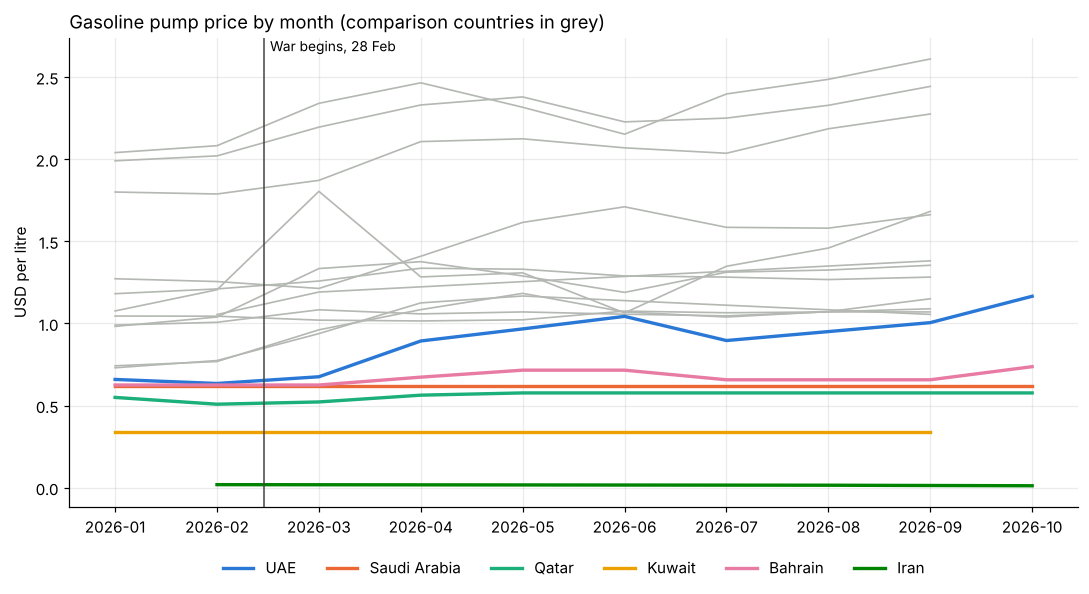

In [5]:
GULF = ["UAE", "Saudi Arabia", "Qatar", "Kuwait", "Bahrain", "Iran"]
COLORS = dict(zip(GULF, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]))
wide = gas.pivot(index="month", columns="country", values="price_usd_per_litre")

fig, ax = plt.subplots(figsize=(10, 5.5))
for c in wide.columns.difference(GULF):
    ax.plot(wide.index, wide[c].interpolate(limit_area="inside"), color="#b4b8b2", lw=1.1)
for c in GULF:
    ax.plot(wide.index, wide[c].interpolate(limit_area="inside"), color=COLORS[c], lw=2.2, label=c)
ax.axvline(1.46, color="#444", lw=1)
ax.text(1.52, ax.get_ylim()[1] * 0.97, "War begins, 28 Feb", fontsize=9)
ax.set_ylabel("USD per litre"); ax.set_title("Gasoline pump price by month (comparison countries in grey)", loc="left")
ax.legend(ncol=6, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.08))
plt.tight_layout(); plt.show()

## 3. How much of the oil shock was passed on

Brent is compared between February (the last pre-war month) and September. The Iranian figure is excluded here because its US dollar price moves with the rial, while the price in rials did not change.

Brent: $70.89 in February to $116.80 in September (+65%)


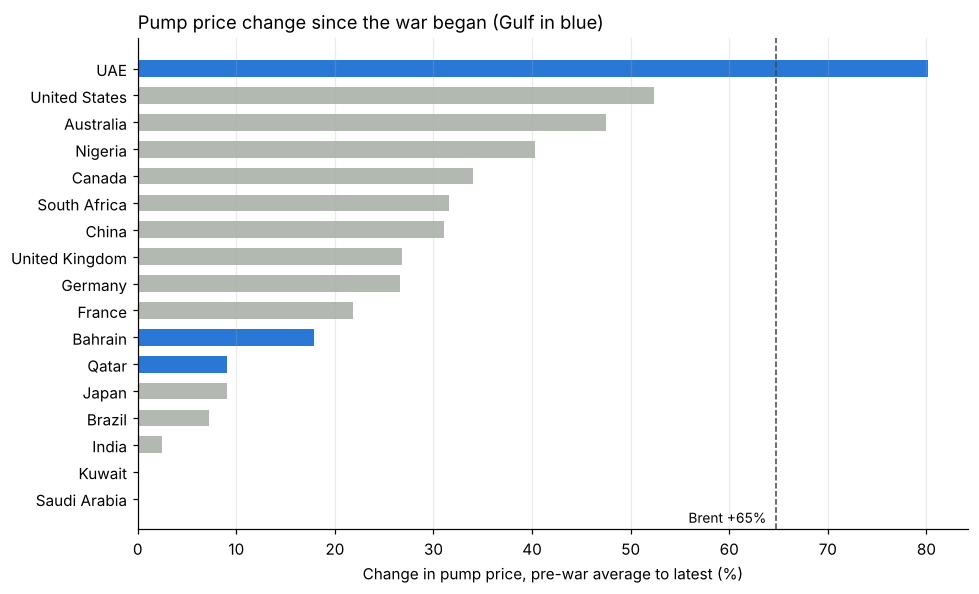

In [6]:
brent = bench.set_index("month").brent_usd_per_bbl
brent_change = (brent["2026-09"] / brent["2026-02"] - 1) * 100
print(f"Brent: ${brent['2026-02']:.2f} in February to ${brent['2026-09']:.2f} in September ({brent_change:+.0f}%)")

passed = summary.reset_index().query("country != 'Iran'")[["group", "country", "change_vs_prewar_pct"]].sort_values("change_vs_prewar_pct")
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(passed.country, passed.change_vs_prewar_pct, color=["#2a78d6" if g == "Gulf" else "#b4b8b2" for g in passed.group], height=0.62)
ax.axvline(brent_change, color="#444", lw=1, ls="--"); ax.text(brent_change - 1, -0.9, f"Brent {brent_change:+.0f}%", ha="right", fontsize=9)
ax.set_xlabel("Change in pump price, pre-war average to latest (%)"); ax.set_title("Pump price change since the war began (Gulf in blue)", loc="left")
ax.grid(axis="y", visible=False); plt.tight_layout(); plt.show()

## 4. Subsidy gap per litre

`gap = reference price x (1 + local VAT) - pump price`

The reference is the UAE pump price before its 5% VAT. The UAE deregulated fuel prices in 2015, so its price is what a Gulf driver pays without state support. The UAE gap is therefore zero by construction.

In [7]:
VAT = {"UAE": 0.05, "Saudi Arabia": 0.15, "Qatar": 0.0, "Kuwait": 0.0, "Bahrain": 0.0, "Iran": 0.0}

def gap_table(fuel, reference):
    g = prices[(prices.fuel == fuel) & (prices.group == "Gulf")].merge(reference.rename("ref_ex_vat"), left_on="month", right_index=True)
    g["gap"] = g.ref_ex_vat * (1 + g.country.map(VAT)) - g.price_usd_per_litre
    return g

uae_ref = prices[(prices.country == "UAE") & (prices.fuel == "gasoline")].set_index("month").price_usd_per_litre / 1.05
gaps = gap_table("gasoline", uae_ref)
gap_summary = gaps.pivot_table(index="country", columns="period", values="gap", aggfunc="mean").loc[GULF].round(3) + 0
gap_summary

period,pre-war,since war
country,,
UAE,0.000,0.000
Saudi Arabia,0.087,0.418
Qatar,0.087,0.336
Kuwait,0.276,0.534
Bahrain,-0.009,0.225
Iran,0.586,0.977


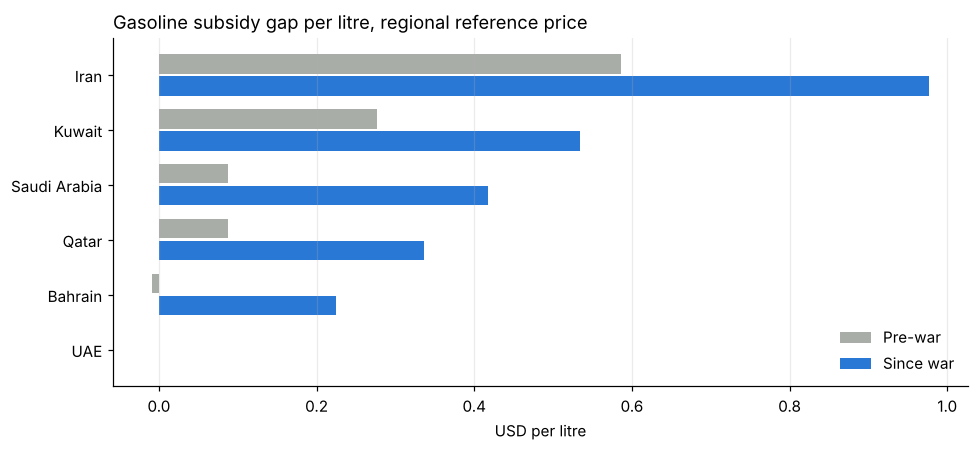

In [8]:
order = gap_summary.sort_values("since war").index
fig, ax = plt.subplots(figsize=(9, 4.2)); y = range(len(order))
ax.barh([i + 0.2 for i in y], gap_summary.loc[order, "pre-war"], height=0.36, color="#a9ada7", label="Pre-war")
ax.barh([i - 0.2 for i in y], gap_summary.loc[order, "since war"], height=0.36, color="#2a78d6", label="Since war")
ax.set_yticks(list(y)); ax.set_yticklabels(order); ax.set_xlabel("USD per litre")
ax.set_title("Gasoline subsidy gap per litre, regional reference price", loc="left")
ax.legend(frameon=False); ax.grid(axis="y", visible=False); plt.tight_layout(); plt.show()

## 5. Annualised subsidy estimate

The gap per litre is multiplied by annual gasoline sales (2023 volumes, OAPEC; Iran from its national distribution company). This is a yearly rate at the prices of each period, not money already spent.

In [9]:
VOLUME_BN_L = {"UAE": 11.37, "Saudi Arabia": 29.55, "Qatar": 2.83, "Kuwait": 5.00, "Bahrain": 1.32, "Iran": 45.26}
annual = gap_summary.mul(pd.Series(VOLUME_BN_L), axis=0).round(1).add(0).rename(columns=lambda c: c + " (USD bn a year)")
annual.loc["GCC five (excluding Iran)"] = annual.drop(index="Iran").sum()
annual

period,pre-war (USD bn a year),since war (USD bn a year)
country,,
UAE,0.000,0.000
Saudi Arabia,2.600,12.400
Qatar,0.200,1.000
Kuwait,1.400,2.700
Bahrain,0.000,0.300
Iran,26.500,44.200
GCC five (excluding Iran),4.200,16.400


The result is checked against the build script's output, so the notebook and the dashboard cannot drift apart.

In [10]:
est = pd.read_csv("../data/processed/subsidy_estimates.csv").query("fuel == 'gasoline'").set_index("country")
check = (gap_summary["since war"] - est.gap_sincewar_regional_usd_l).abs().max()
assert check < 0.001, check
print("Largest difference from scripts/build_data.py output:", round(check, 4), "USD per litre")

Largest difference from scripts/build_data.py output: 0.0 USD per litre


## 6. Sensitivity to the reference price

The alternative reference is the US Gulf Coast spot price plus $0.185 a litre for distribution, the midpoint of the IMF range. US spot ran above Asian spot in 2026, so this version gives a higher estimate.

In [11]:
intl_ref = bench.set_index("month").usgc_gasoline_spot_usd_per_litre.dropna() + 0.185
gaps_intl = gap_table("gasoline", intl_ref)
intl = gaps_intl.pivot_table(index="country", columns="period", values="gap", aggfunc="mean").loc[GULF]
compare = pd.DataFrame({
    "regional (USD bn a year)": gap_summary["since war"].mul(pd.Series(VOLUME_BN_L)),
    "international (USD bn a year)": intl["since war"].mul(pd.Series(VOLUME_BN_L)),
}).round(1) + 0
compare.loc["GCC five (excluding Iran)"] = compare.drop(index="Iran").sum()
compare

,regional (USD bn a year),international (USD bn a year)
country,,
UAE,0.000,2.100
Saudi Arabia,12.400,17.400
Qatar,1.000,1.400
Kuwait,2.700,3.600
Bahrain,0.300,0.500
Iran,44.200,50.000
GCC five (excluding Iran),16.400,25.000


## 7. Findings and limits

**Findings**
- Brent rose 65% between February and September. Saudi Arabia and Kuwait did not change the pump price. Qatar rose 9% and Bahrain 18%.
- The UAE, which follows the world market, rose 80% and now charges about what US drivers pay.
- The estimated gasoline subsidy for the five GCC states rose from about \$4bn a year at pre-war prices to about \$16bn a year since March on the regional reference, or about \$25bn on the international one. Saudi Arabia is the largest share on either basis.
- The increase came from the world price moving, with no change in pricing policy.

**Limits**
- Sales volumes are for 2023 and one grade is used per country, so totals are orders of magnitude.
- Iran depends heavily on the exchange rate chosen and has few dated readings. Its volumes include smuggled fuel.
- China, Australia and Canada are single-day readings. Nigeria has no national average after May. Kuwait's fourth-quarter price was not published when the data was collected.
- Grades differ between regions (95 octane in the Gulf and Europe, regular in North America).